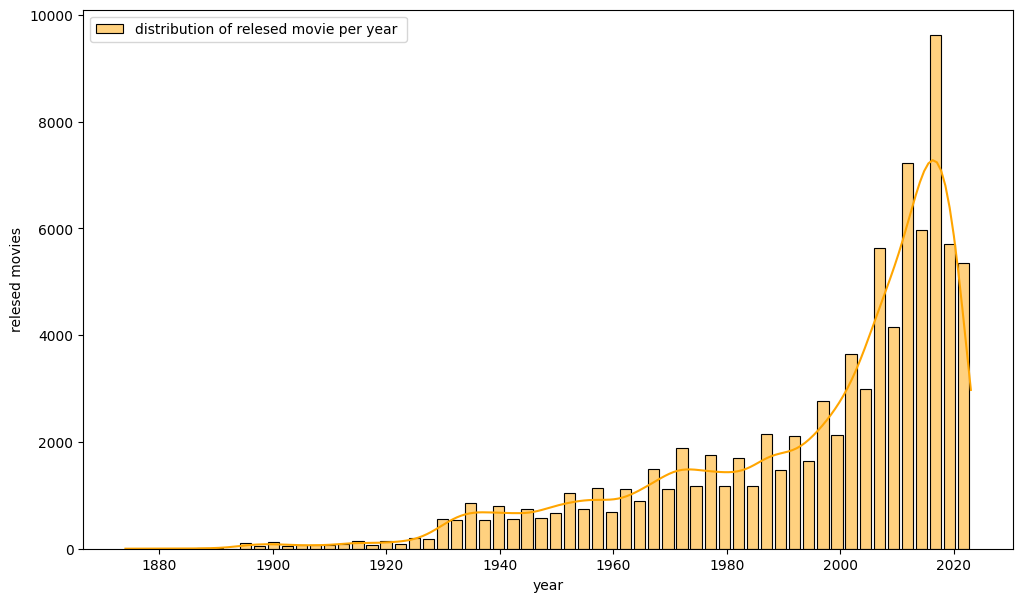

In [1]:
#movie realsed per year

import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns 

movies = pd.read_csv("/Users/meetnakrani/Library/Mobile Documents/com~apple~CloudDocs/recommendation-engine-platform/data/processed/movies_clean.csv")
movies.head()
plt.figure(figsize=(12,7))
sns.histplot(movies['year'], bins=60, color="orange", edgecolor = "black", shrink= 0.8, label="distribution of relesed movie per year ", kde = True)
plt.xlabel("year")
plt.ylabel("relesed movies")
plt.legend()
plt.show()

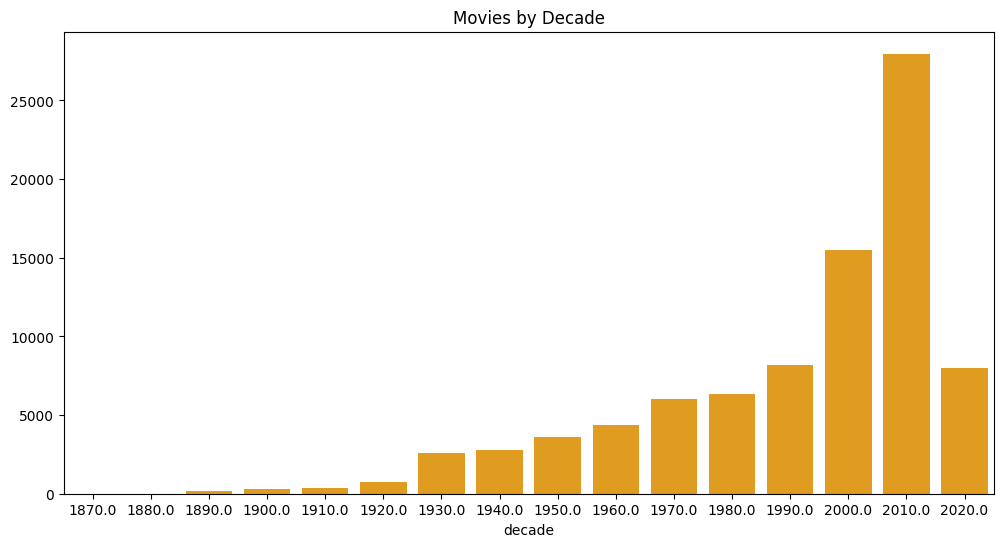

In [46]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns 

movies_df = pd.read_csv("/Users/meetnakrani/Library/Mobile Documents/com~apple~CloudDocs/recommendation-engine-platform/data/processed/movies_clean.csv")

movies_df['decade'] = (movies_df["year"]//10)*10

decade_count = movies_df['decade'].value_counts().sort_index()

plt.figure(figsize=(12,6))

sns.barplot(
    x=decade_count.index,
    y=decade_count.values,
    color="orange"
)

plt.title("Movies by Decade")

plt.show() 

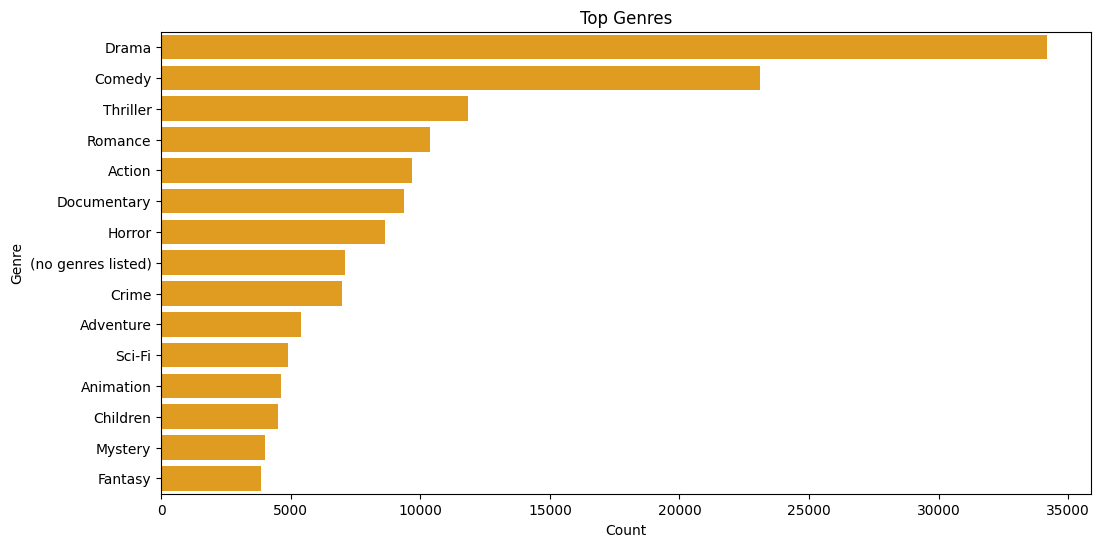

In [40]:
from collections import Counter

genre_counter = Counter()

for genres in movies_df['genre_list'].dropna():
    genres = str(genres).replace("[","").replace("]","").replace("'","")
    
    for g in genres.split(","):
        genre_counter[g.strip()] += 1

genre_df = pd.DataFrame(
    genre_counter.items(),
    columns=['Genre','Count']
)

genre_df = genre_df.sort_values(
    'Count',
    ascending=False
).head(15)

plt.figure(figsize=(12,6))

sns.barplot(
    data=genre_df,
    color="orange",
    x='Count',
    y='Genre'
)

plt.title('Top Genres')

plt.show()

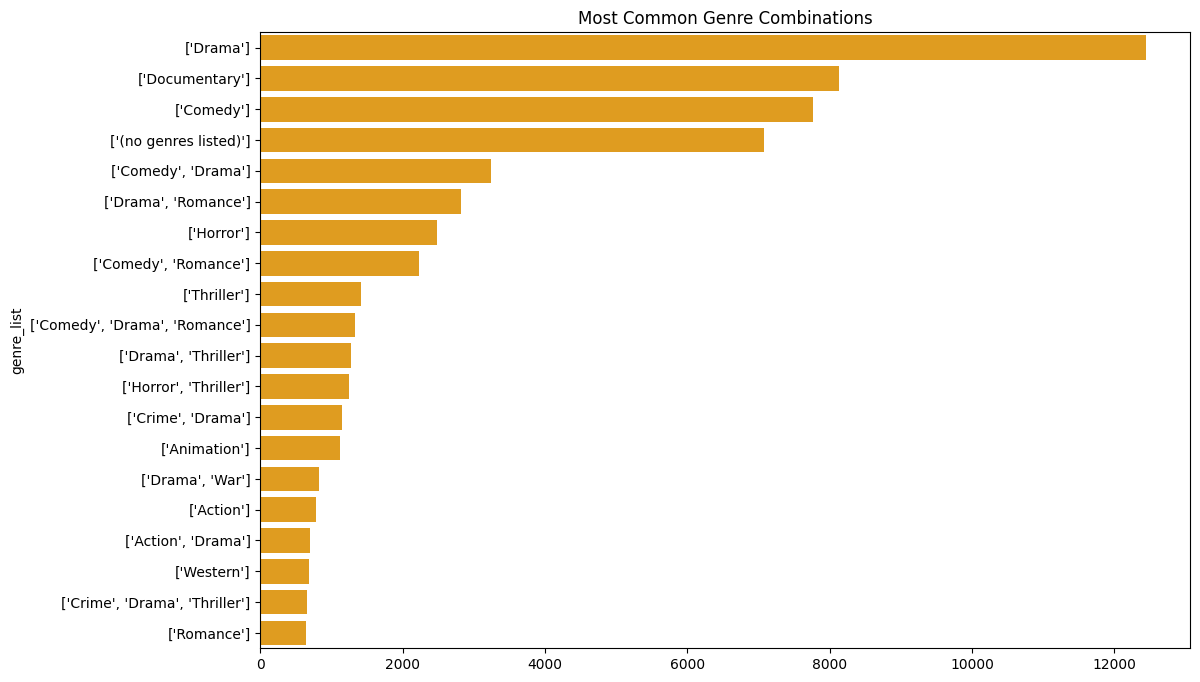

In [48]:
combo = movies_df['genre_list'].astype(str)

top_combo = combo.value_counts().head(20)

plt.figure(figsize=(12,8))

sns.barplot(
    x=top_combo.values,
    y=top_combo.index,
    color ="orange"
)

plt.title("Most Common Genre Combinations")

plt.show()

In [ ]:


genre_ratings = []

for _, row in movies_df.iterrows():

    for genre in row['genre_list']:

        genre_ratings.append(
            [genre,row['avg_rating_x']]
        )

genre_rating_df = pd.DataFrame(
    genre_ratings,
    columns=['Genre','Rating']
)

avg_genre = (
    genre_rating_df
    .groupby('Genre')['Rating']
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12,6))

sns.barplot(
    x=avg_genre.values,
    y=avg_genre.index
)

plt.title("Average Rating by Genre")

plt.show()

KeyError: 'avg_rating'